# Importacion de liberias

In [2]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from boruta import BorutaPy

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV,train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# Cargue de datos

In [3]:
df_aporte = pd.read_csv('../data/raw/empresas afiliadas.csv')

In [4]:
df_aporte.columns

Index(['id_empresa', 'ciudad', 'sector', 'antiguedad_empresa',
       'distancia_centro', 'productividad', 'numero_trabajadores',
       'salario_promedio', 'rotacion_personal', 'crecimiento_nomina',
       'numero_servicios', 'indice_formalizacion', 'indice_digitalizacion',
       'indice_competencia', 'satisfaccion_servicio', 'aporte_mensual'],
      dtype='object')

# Entrenamiento y testeo de modelos

### Analisis de multicolinelidad

Este analisis lo realizamos con el fin de identifciar que varibles estan almanete relacionadas y evitar darle posible información redundante a los modelos lineales

In [5]:

X = df_aporte.select_dtypes(include=np.number)

# quitar variable objetivo
X = X.drop(columns=["aporte_mensual","id_empresa"])

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

                 Variable         VIF
8    indice_formalizacion  107.414067
2           productividad   93.325829
9   indice_digitalizacion   81.258034
11  satisfaccion_servicio   56.932839
4        salario_promedio   43.333868
5       rotacion_personal    9.114811
10     indice_competencia    3.997239
1        distancia_centro    3.961815
0      antiguedad_empresa    3.505313
7        numero_servicios    2.913991
6      crecimiento_nomina    1.978839
3     numero_trabajadores    1.895242


### Boruta

Se aplica boruta con el fin de identificar cuales son las variables que me aportan información útil en la predicción de la variable objetivo (aporte_mensual) y verificar si estas mismas hacen parte de las que cuentan con mayor multicolinealidad identificadas en el paso anterior

In [6]:
X = df_aporte.drop(columns=['aporte_mensual','id_empresa'])
y = df_aporte['aporte_mensual']

In [7]:
numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

X_pre = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_pre = pd.DataFrame(
    X_pre,
    columns=feature_names,
    index=X.index
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    random_state=42
)

boruta.fit(X_pre.values, y.values)
variables = X_pre.columns[boruta.support_]

print(variables)

ranking = pd.DataFrame({
    "Variable": X_pre.columns,
    "Ranking": boruta.ranking_,
    "Seleccionada": boruta.support_
})

ranking.sort_values("Ranking")



Index(['num__antiguedad_empresa', 'num__distancia_centro',
       'num__productividad', 'num__numero_trabajadores',
       'num__salario_promedio', 'num__rotacion_personal',
       'num__crecimiento_nomina', 'num__numero_servicios',
       'num__indice_formalizacion', 'num__indice_digitalizacion'],
      dtype='object')


,Variable,Ranking,Seleccionada
0,num__antiguedad_empresa,1,True
1,num__distancia_centro,1,True
2,num__productividad,1,True
3,num__numero_trabajadores,1,True
4,num__salario_promedio,1,True
5,num__rotacion_personal,1,True
6,num__crecimiento_nomina,1,True
7,num__numero_servicios,1,True
8,num__indice_formalizacion,1,True
9,num__indice_digitalizacion,1,True


<Axes: >

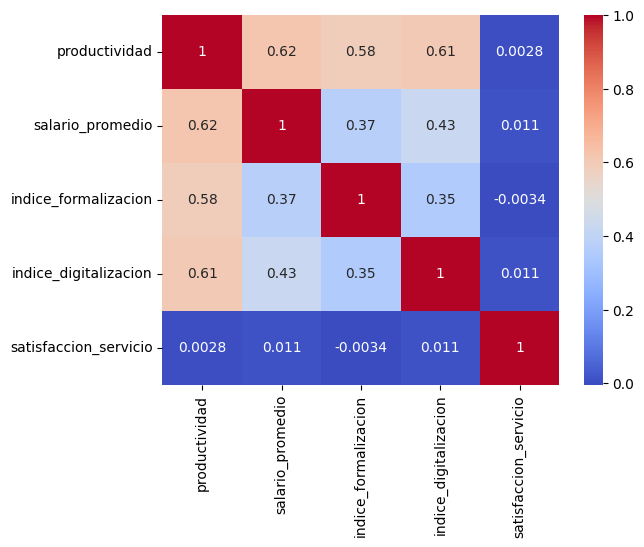

In [8]:
cols = [
    "productividad",
    "salario_promedio",
    "indice_formalizacion",
    "indice_digitalizacion",
    "satisfaccion_servicio"
]

sns.heatmap(df_aporte[cols].corr(),
            annot=True,
            cmap="coolwarm")



Dados los resultdos de boruta, se decide continuar con las columnas sugeridas y validar su desempeño en el modelo

## Variables Boruta

In [9]:
variables_boruta = [
    "antiguedad_empresa",
    "distancia_centro",
    "productividad",
    "numero_trabajadores",
    "salario_promedio",
    "rotacion_personal",
    "crecimiento_nomina",
    "numero_servicios",
    "indice_formalizacion",
    "indice_digitalizacion"
]

In [10]:
X = df_aporte[variables_boruta]
y = df_aporte['aporte_mensual']

x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

### XGBOOST

In [11]:
numeric_features = x_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = x_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

In [12]:
modelo_xgb = XGBRegressor(
    obejetive = 'reg:squarederror',
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 123)

pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", modelo_xgb)
])

pipeline_xgb.fit(x_train, y_train)

C:\Users\NATHNIEAYA\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [22:18:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obejetive" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['antiguedad_empresa',
                                                   'distancia_centro',
                                                   'productividad',
                                                   'numero_trabajadores',
                                                   'salario_promedio',
                                                   'rotacion_personal',
                                                   'crecimiento_nomina',
                                                   'numero_servicios',
                                                   'indice_formalizacion',
                                                   'indice_digitalizacion']),
                                                 ('cat',
                                                  Pi...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None,
                              obejetive='reg:squarederror', ...))])

In [13]:
pred = pipeline_xgb.predict(x_test)

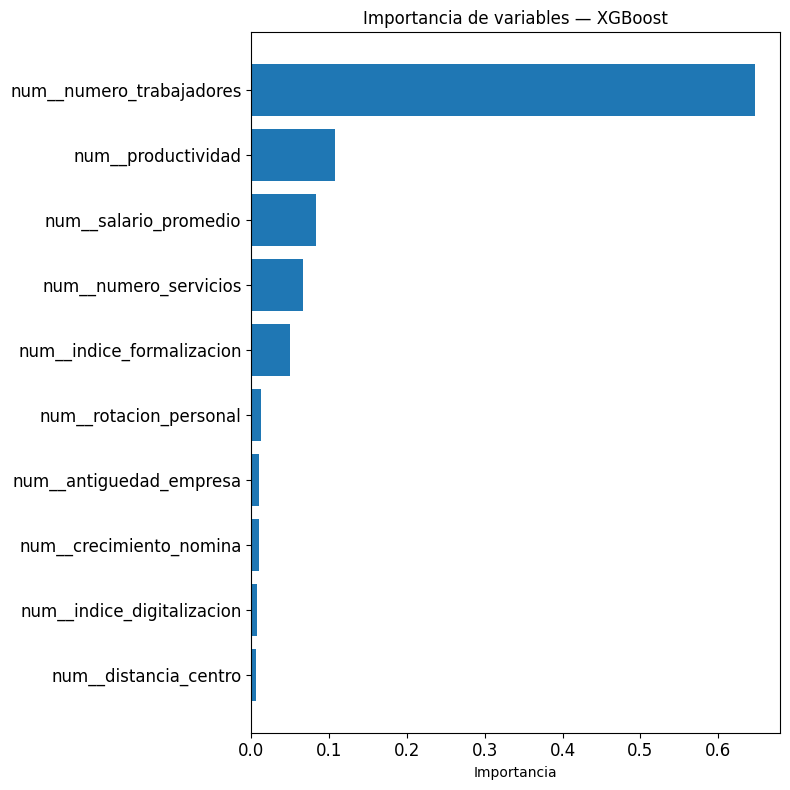

In [33]:
feature_names = pipeline_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias = pd.DataFrame({

    "Variable":feature_names,

    "Importancia":pipeline_xgb.named_steps[
        "model"
    ].feature_importances_

})

importancias.sort_values(
    "Importancia",
    ascending=False
)

top_n = importancias.head(15).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 8))
plt.barh(top_n["Variable"][::-1], top_n["Importancia"][::-1])
plt.xlabel("Importancia")
plt.title("Importancia de variables — XGBoost")

# Tamaño de las etiquetas de los ejes13
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
importancias.head(15).sort_values(by='Importancia', ascending=False)

,Variable,Importancia
3,num__numero_trabajadores,0.646868
2,num__productividad,0.107814
4,num__salario_promedio,0.083114
7,num__numero_servicios,0.066135
8,num__indice_formalizacion,0.049611
5,num__rotacion_personal,0.012356
0,num__antiguedad_empresa,0.010395
6,num__crecimiento_nomina,0.010254
9,num__indice_digitalizacion,0.007487
1,num__distancia_centro,0.005966


In [54]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred))
mae_xgb = mean_absolute_error(y_test, pred)
r2_xgb = r2_score(y_test, pred)
mape_xgb= mean_absolute_percentage_error(y_test, pred)

print("RMSE :", rmse_xgb)
print("MAE  :", mae_xgb)
print("R2 :", r2_xgb)
print("MAPE :", mape_xgb)

RMSE : 926186.6955844713
MAE  : 443356.70725
R2 : 0.9653793947853513
MAPE : 0.03942528109346567


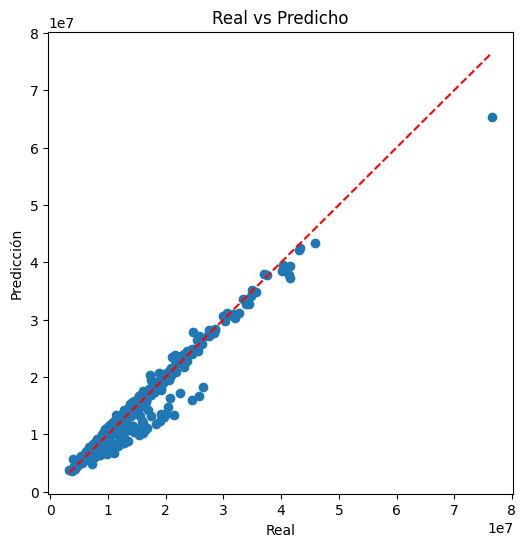

In [51]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicho")
plt.show()

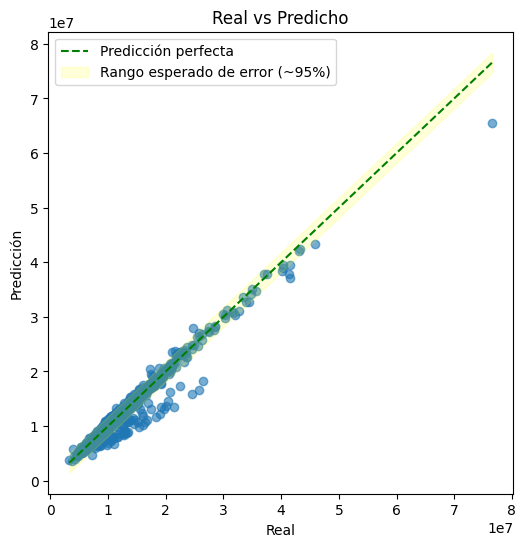

In [18]:
import numpy as np

residuales = y_test - pred
rmse = np.sqrt(np.mean(residuales**2))

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.6)

x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, x_line, 'g--', label="Predicción perfecta")

# Banda de error de ±1.96*RMSE (aprox. 95% de las predicciones)
plt.fill_between(
    x_line,
    x_line - 1.96 * rmse,
    x_line + 1.96 * rmse,
    color='yellow',
    alpha=0.15,
    label="Rango esperado de error (~95%)"
)

plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicho")
plt.legend()
plt.show()

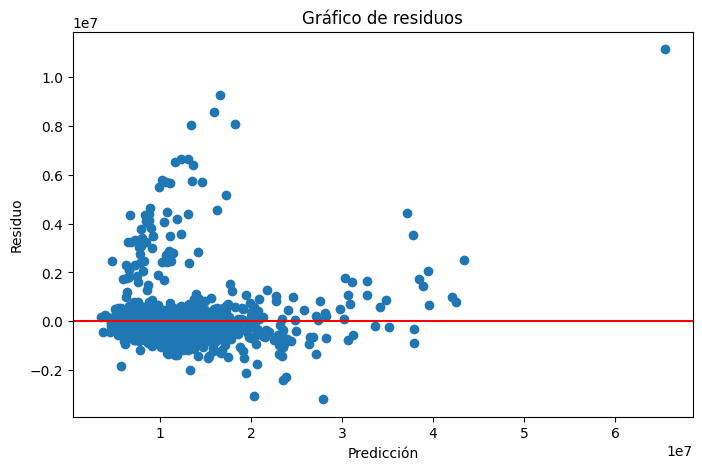

In [20]:
residuos = y_test - pred

plt.figure(figsize=(8,5))
plt.scatter(pred, residuos)
plt.axhline(0, color="red")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Gráfico de residuos")
plt.show()

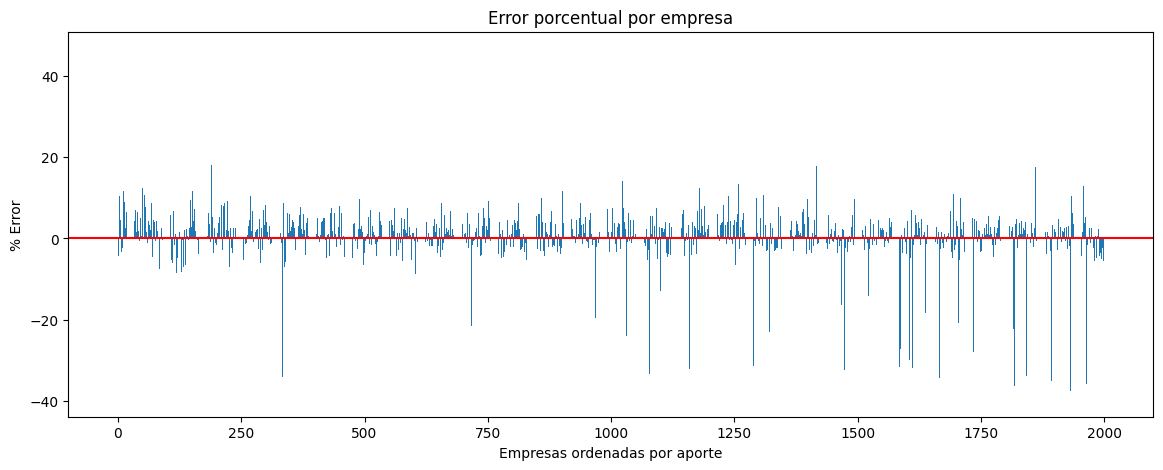

In [21]:
resultado = pd.DataFrame({
    "Real": y_test,
    "Predicción": pred
})

resultado["Error_%"] = (
    (resultado["Predicción"]-resultado["Real"])
    /resultado["Real"]*100
)

resultado = resultado.sort_values("Real")

plt.figure(figsize=(14,5))

plt.bar(
    range(len(resultado)),
    resultado["Error_%"]
)

plt.axhline(0,color="red")

plt.xlabel("Empresas ordenadas por aporte")
plt.ylabel("% Error")

plt.title("Error porcentual por empresa")

plt.show()

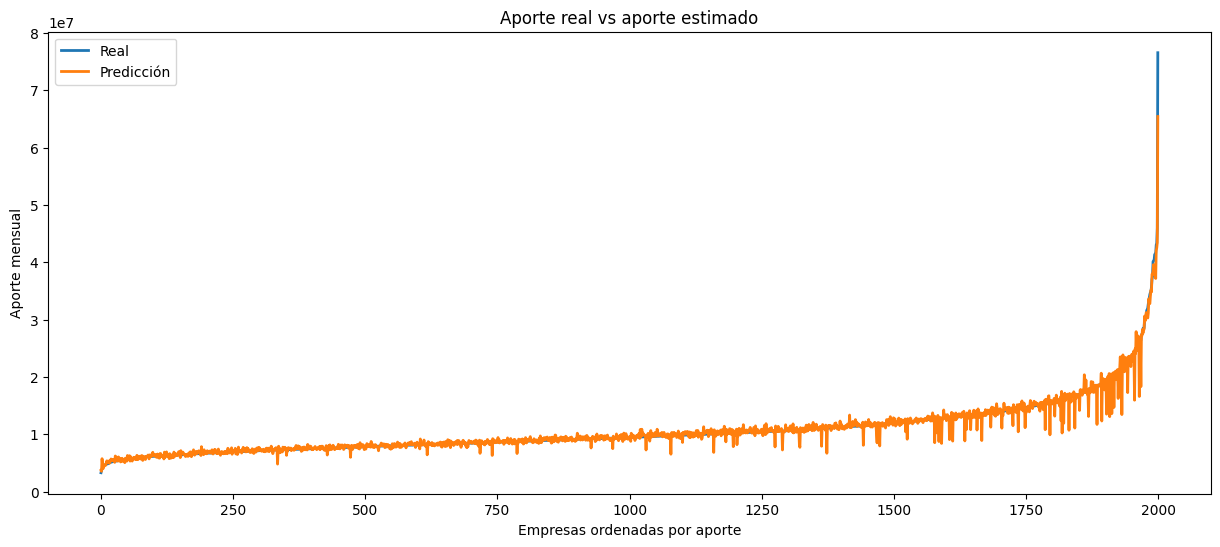

In [71]:
resultado = resultado.sort_values("Real")

plt.figure(figsize=(15,6))

plt.plot(
    resultado["Real"].values,
    label="Real",
    linewidth=2
)

plt.plot(
    resultado["Predicción"].values,
    label="Predicción",
    linewidth=2
)

plt.legend()

plt.xlabel("Empresas ordenadas por aporte")
plt.ylabel("Aporte mensual")

plt.title("Aporte real vs aporte estimado")

plt.show()

In [22]:
resultado

,Real,Predicción,Error_%
1339,3277921.0,3706057.75,13.061228
3889,3685959.0,3527798.00,-4.290905
8701,3908972.0,5726406.00,46.493912
6440,4097697.0,4521266.00,10.336757
4649,4251976.0,3990015.75,-6.160906
...,...,...,...
6749,41580436.0,37163736.00,-10.622063
9187,43031225.0,42046832.00,-2.287625
3574,43309423.0,42504556.00,-1.858411
8310,45944649.0,43419380.00,-5.496329


In [37]:
pd.concat([x_test, resultado], axis=1).describe()

,antiguedad_empresa,distancia_centro,productividad,numero_trabajadores,salario_promedio,rotacion_personal,crecimiento_nomina,numero_servicios,indice_formalizacion,indice_digitalizacion,Real,Predicción,Error_%
count,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2000.000000
mean,13.50635,40.30233,61.377100,21.128000,4.041640,20.077550,5.943750,1.328000,66.721100,65.421050,1.066132e+07,1.064240e+07,0.366774
std,10.93624,22.89041,10.758261,25.244965,0.825554,7.800504,6.025026,1.168374,8.184031,8.923548,4.978973e+06,4.795480e+06,6.506119
min,1.00000,0.01000,19.100000,1.000000,1.690000,0.000000,-11.900000,0.000000,36.000000,32.100000,3.277921e+06,3.527798e+06,-39.520273
25%,5.90000,20.49000,53.800000,7.000000,3.457500,14.375000,1.875000,0.000000,61.200000,59.600000,7.825126e+06,7.822974e+06,-1.511580
50%,10.15000,39.57500,60.900000,14.000000,4.000000,20.500000,6.000000,1.000000,66.700000,65.450000,9.447756e+06,9.465900e+06,0.953355
75%,17.12500,60.29250,68.700000,26.000000,4.560000,25.700000,9.900000,2.000000,72.300000,71.800000,1.195011e+07,1.188037e+07,3.547219
max,60.00000,79.98000,95.000000,353.000000,6.680000,45.600000,26.600000,10.000000,99.000000,93.400000,7.654771e+07,6.541352e+07,46.493912


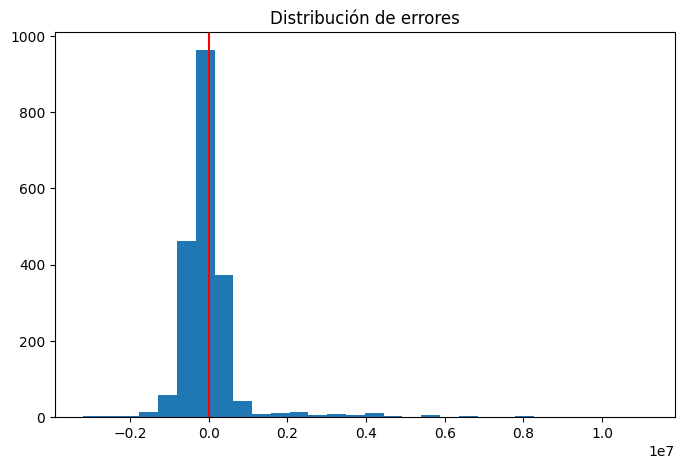

In [72]:
errores = y_test-pred

plt.figure(figsize=(8,5))

plt.hist(errores,bins=30)

plt.axvline(0,color="red")

plt.title("Distribución de errores")

plt.show()

### LXGBM

In [ ]:
modelo_lgbm = LGBMRegressor(
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 123)

pipeline_lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", modelo_lgbm)
])

pipeline_lgbm.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2182
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] Start training from score 10491351.746625
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['antiguedad_empresa',
                                                   'distancia_centro',
                                                   'productividad',
                                                   'numero_trabajadores',
                                                   'salario_promedio',
                                                   'rotacion_personal',
                                                   'crecimiento_nomina',
                                                   'numero_servicios',
                                                   'indice_formalizacion',
                                                   'indice_digitalizacion']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03,
                               max_depth=4, n_estimators=500, random_state=123,
                               subsample=0.8))])

In [58]:
pred_lgbm = pipeline_lgbm.predict(x_test)

In [59]:
feature_names = pipeline_lgbm.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias = pd.DataFrame({

    "Variable":feature_names,

    "Importancia":pipeline_lgbm.named_steps[
        "model"
    ].feature_importances_

})

importancias.sort_values(
    "Importancia",
    ascending=False
)

,Variable,Importancia
3,num__numero_trabajadores,1372
4,num__salario_promedio,826
2,num__productividad,623
6,num__crecimiento_nomina,589
8,num__indice_formalizacion,535
0,num__antiguedad_empresa,429
9,num__indice_digitalizacion,368
7,num__numero_servicios,357
5,num__rotacion_personal,293
1,num__distancia_centro,175


In [60]:
rmse_lgbm = np.sqrt(mean_squared_error(y_test, pred_lgbm))
mae_lgbm = mean_absolute_error(y_test, pred_lgbm)
mape_lgmb = mean_absolute_percentage_error(y_test, pred_lgbm)
r2_lgbm = r2_score(y_test,pred_lgbm)

print("RMSE :", rmse_lgbm)
print("MAE  :", mae_lgbm)
print("R2 :", r2_lgbm)
print("MAPE :", mape_lgmb)

RMSE : 1082346.0041778404
MAE  : 463809.45002950885
R2 : 0.9527208330678838
MAPE : 0.040056915576369805


### Regresion Lineal

In [64]:
pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipeline_lr.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['antiguedad_empresa',
                                                   'distancia_centro',
                                                   'productividad',
                                                   'numero_trabajadores',
                                                   'salario_promedio',
                                                   'rotacion_personal',
                                                   'crecimiento_nomina',
                                                   'numero_servicios',
                                                   'indice_formalizacion',
                                                   'indice_digitalizacion']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('model', LinearRegression())])

In [65]:
pred_lr = pipeline_lr.predict(x_test)

In [69]:
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, pred_lr)
r2_lr = r2_score(y_test,pred_lr)

print("RMSE :", rmse_lr)
print("MAE  :", mae_lr)
print("R2 :", r2_lr)
print("MAPE :", mape_lr)

RMSE : 1153905.7326975274
MAE  : 641267.0663879957
R2 : 0.9462624031028123
MAPE : 0.05790789673952034


In [75]:
joblib.dump(pipeline_xgb, "../models/modelo_regresion_aportes.pkl")


['../models/modelo_regresion_aportes.pkl']